# Genome Assembly and Analysis of Bacterial Isolates

## Introduction

In this tutorial, we will learn how to process ONT Nanopore and Illumina sequencing data from bacterial isolates to generate high-quality genome assemblies. We will cover quality control of raw sequencing reads, genome assembly, polishing and gene prediction. We will work with a public dataset containing paired sequencing data generated with the ONT GridION sequencer and the Illumina NextSeq 2000. Accessions for downloading the raw sequencing data are given at the end of this document - for now, we want to keep the bacterial species a mystery to solve as a task of this workshop.

## Topics

- Processing Nanopore sequencing data
    - Quality Control
    - Assembly
    - Polishing
- Processing Illumina sequencing data
    - Quality Control
    - Assembly
- Short read polishing
- Finalizing Assemblies
    - Re-Orientation
    - Quality and Completness assessment
    - Gene prediction
- Query gene annotations

### Setup

First, we need to import some modules and set paths.

In [1]:
import os
import pandas as pd
from IPython.display import Image, HTML, display

In [2]:
results_dir = "/biodata/results/day3_lab1/"
resources_dir = "/biodata/resources/day3_lab1/"
os.system(f"mkdir -p {results_dir}")
# ensure that all required resources are existing
for path_ in [
        f"{resources_dir}/raw_reads/ONT.fastq.gz",
        f"{resources_dir}/raw_reads/25748_R1.fastq.gz",
        f"{resources_dir}/raw_reads/25748_R2.fastq.gz",
        f"{resources_dir}/fastqc/fastqc_R1.png",
        f"{resources_dir}/graphs/assembly_graph_spades.png",
        f"{resources_dir}/checkm",
        f"{resources_dir}/prokka",]:
    assert os.path.exists(path_), f"Resource does not exist but is required: {path_}"


## Processing Nanopore Sequencing Data

**TL;DR** The ONT data is pre-processed for assembly, only quality control still needs to be performed

The "raw" Nanopore sequencing data used in this tutorial is already preprocessed to some degree, since it is already in FASTQ format. In contrast to Illumina data, the RAW data format of a Nanopore sequencing experiment (POD5 or FAST5) is valuable to keep, since it containes more information than stored in FASTQ files, e.g. epigenetic  information on nucleotide modifications.

After sequencing, the first step is to deduce the nucleobase sequence from the current measurements of each sequencing read - a process called **basecalling**. Most ONT sequencers have the capability to perform live-basecalling, producing FASTQ reads while the sequencing experiment is still running and new sequencing data is produced, allowing for real-time bioinformatic analyses. In out case, I used the newest available basecalling model of ONT Dorado, sup@v5.2.0, to get the highest basecalling quality currently achieveable.

Additional pre-processing steps are **demultiplexing** and **adapter trimming**. In most cases, the yield of a sequencing run is too large to sequence only a single bacterial genome, and more data would be generated than needed for assembly. The solution is multiplexing: Special sequencing adapters containing barcode sequences are used to label DNA of different samples (up to 96), before they are combined in the final steps of sequencing library preparation. Dorado automatically detects and trimms there adapters from the produced sequencing reads. The corresponding barcode is stored together with each read in a BAM file. This information can be used to demultiplex the data produced by the sequencer and to generate individual FASTQ files for each sample. 

ⓘ If encountering reads in FASTQ format that are not yet trimmed, you can use the tool *porechop-ABI*

For this tutorial, the sequencing data of the sequenced strain was **subsampled** to a sequencing depth of approx. 50x using the tool *rasusa* to make the data size manageable.

### Quality Control

*NanoPlot* is a useful tool to assess the quality of Nanopore sequencing data. It produces general summary statistics as a text output and plots in HTML format. The most important features are the **length** of sequencing reads and their **quality**.

The longer the reads are, the easier is the assembly. Long reads reduce the likelihood that repetetive regions of the chromosome are not spanned, which will lead to incomplete, fragmented assemblies. This is the big advantage of long read seqeuncing technologies like ONT Nanopore sequencing and PacBio SMRT sequencing.

The quality of reads is essential for generating high-quality assemblies. Low quality reads can result in mismatches or insertions / delitions (indels) in the assembly compared to the true genome sequence. Illumina short reads are of higher quality and historically, hybrid assemblies were required to ensure sufficient quality, especially for tasks like genotyping. However, with recent technological advances, the quality of ONT-only assemblies has increased. 

ⓘ Short Nanopore reads are often of lower quality than long ones, because the quality drops towards the end of sequencing reads.

In [4]:
os.system(f'NanoPlot --fastq {resources_dir}/raw_reads/ONT.fastq.gz -o {results_dir}/NanoPlot/pre_filter/')
os.system(f"cat {results_dir}/NanoPlot/pre_filter/NanoStats.txt")

This command requires Kaleido v1.0.0 or greater.
Install it using `pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`."



General summary:         
Mean read length:                4,221.6
Mean read quality:                  18.7
Median read length:              1,354.0
Median read quality:                21.2
Number of reads:                37,372.0
Read length N50:                13,798.0
STDEV read length:               7,944.7
Total bases:               157,768,302.0
Number, percentage and megabases of reads above quality cutoffs
>Q10:	37256 (99.7%) 157.5Mb
>Q15:	33527 (89.7%) 148.2Mb
>Q20:	22500 (60.2%) 116.6Mb
>Q25:	6980 (18.7%) 34.8Mb
>Q30:	838 (2.2%) 1.4Mb
Top 5 highest mean basecall quality scores and their read lengths
1:	41.3 (2362)
2:	40.9 (1026)
3:	40.8 (444)
4:	40.5 (572)
5:	40.4 (2233)
Top 5 longest reads and their mean basecall quality score
1:	115369 (22.1)
2:	94829 (12.9)
3:	94363 (18.0)
4:	93236 (22.9)
5:	92102 (22.4)


0

In [52]:
display(HTML(f"{results_dir}/NanoPlot/pre_filter/WeightedLogTransformed_HistogramReadlength.html"))
display(HTML(f"{results_dir}/NanoPlot/pre_filter/LengthvsQualityScatterPlot_dot.html"))

<div style="border-left: 4px solid #007acc; padding: 0.5em; background: rgba(0, 122, 204, 0.1); border-radius: 4px;">
<strong>📝 Question :</strong> What could the peak at 3.1 Kbp mean?
</div>

<details>
<summary><strong>🔎 Solution :</strong></summary>

 <ul>
  <li>Individual peaks can indicate presence of high-copy plasmids</li>
  <li>For amplified sequencing libraries, they could also be PCR artifacts</b></li>
</ul> 

</details>

We will now filter the sequencing reads with the tool *filtlong*. Instead of removing all reads below a certain phread score threshold, we will remove all short reads below 1 Kbp, since they are not too useful for assembly anyways, and also only keep the 95 % of reads with the highest quality.

The reason is that by filtering strictly by quality, we might loose all reads of a small plasmid, because naturally all its reads are short and therefore of lower quality. Still, we need to inspect the histogram carefully if the length cutoff is a safe filter threshold.

In [7]:
os.system(f'filtlong --min_length 1000 --keep_percent 95 {resources_dir}/raw_reads/ONT.fastq.gz > {results_dir}/ONT_filtered.fastq')


Scoring long reads
  37372 reads (157768302 bp)

Filtering long reads
  target: 149879886 bp
  reads already fall below target after filtering

Outputting passed long reads



0

We can now re-run NanoPlot to compare how filtering affected the read stats.

In [8]:
os.system(f'NanoPlot --only-report --fastq {results_dir}/ONT_filtered.fastq -o {results_dir}/NanoPlot/post_filter/')
os.system(f"head -n15 {results_dir}/NanoPlot/post_filter/NanoStats.txt")

This command requires Kaleido v1.0.0 or greater.
Install it using `pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`."



General summary:         
Mean read length:                6,819.4
Mean read quality:                  19.8
Median read length:              3,107.0
Median read quality:                22.3
Number of reads:                21,793.0
Read length N50:                15,373.0
STDEV read length:               9,592.9
Total bases:               148,615,612.0
Number, percentage and megabases of reads above quality cutoffs
>Q10:	21763 (99.9%) 148.4Mb
>Q15:	20452 (93.8%) 140.4Mb
>Q20:	15351 (70.4%) 112.2Mb
>Q25:	4819 (22.1%) 33.5Mb
>Q30:	419 (1.9%) 1.1Mb


0

As you can see, the Median read length more then doubled, from 1,354 to 3,107.


We can use the tool *lrge* to get a first estimate of the genome size of the organism that was sequenced, prior to assembly.

In [9]:
os.system(f'lrge -t 16 {results_dir}/ONT_filtered.fastq')

[2025-09-30T09:23:52Z INFO  lrge] Running two-set strategy with 10000 target reads and 5000 query reads


2770235


[2025-09-30T09:24:03Z INFO  liblrge::twoset] 74 (1.48%) query read(s) did not overlap any target reads
[2025-09-30T09:24:03Z INFO  lrge] Estimated genome size: 2.77 Mbp (IQR: 1.19 Mbp - 3.33 Mbp)
[2025-09-30T09:24:03Z INFO  lrge] Done!


0

<div style="border-left: 4px solid #007acc; padding: 0.5em; background: rgba(0, 122, 204, 0.1); border-radius: 4px;">
<strong>📝 Question :</strong> What is the expected sequencing depth?
</div>

<details>
<summary><strong>🔎 Solution :</strong></summary>

The sequencing depth is the total number of bases divided by the expected genome size:

148.6 Mbp / 2.7 Mbp = 55

</details>

### Assembly

We now perform genome assembly using *flye*.

In [10]:
# --asm-coverage 50 --genome-size {gsize}
os.system(f'flye --nano-hq {results_dir}/ONT_filtered.fastq -o {results_dir}/flye_assembly --threads 32')

[2025-09-30 09:24:21] INFO: Starting Flye 2.9.6-b1802
[2025-09-30 09:24:21] INFO: >>>STAGE: configure
[2025-09-30 09:24:21] INFO: Configuring run
[2025-09-30 09:24:22] INFO: Total read length: 148615612
[2025-09-30 09:24:22] INFO: Reads N50/N90: 15373 / 2563
[2025-09-30 09:24:22] INFO: Minimum overlap set to 3000
[2025-09-30 09:24:22] INFO: >>>STAGE: assembly
[2025-09-30 09:24:22] INFO: Assembling disjointigs
[2025-09-30 09:24:22] INFO: Reading sequences
[2025-09-30 09:24:22] INFO: Building minimizer index
[2025-09-30 09:24:22] INFO: Pre-calculating index storage
0% 10% 20% 30% 40% 50% 60% 70% 80% 90% 100% 
[2025-09-30 09:24:26] INFO: Filling index
0% 10% 20% 30% 40% 50% 60% 70% 80% 90% 100% 
[2025-09-30 09:24:35] INFO: Extending reads
[2025-09-30 09:24:58] INFO: Overlap-based coverage: 38
[2025-09-30 09:24:58] INFO: Median overlap divergence: 0.0106699
0% 90% 100% 
[2025-09-30 09:25:16] INFO: Assembled 6 disjointigs
[2025-09-30 09:25:16] INFO: Generating sequence
0% 10% 20% 30% 40% 50

0

The assembler produces several output files that are of interest:

- assembly.fasta : The assembled contig sequences
- assembly_graph.gfa : The assembly graph, storing information on how the contigs are likely arranged in the genome
- assembly_info.txt : Tabular overview of assembled contigs including their length, circularity and coverage

In [11]:
os.system(f"cat {results_dir}/flye_assembly/assembly_info.txt")

#seq_name	length	cov.	circ.	repeat	mult.	alt_group	graph_path
contig_4	3049602	45	Y	N	1	*	4
contig_1	27327	108	Y	Y	3	*	1
contig_2	3944	166	N	N	4	*	*,2,*
contig_3	3566	122	N	N	4	*	*,3,*


0

<div style="border-left: 4px solid #007acc; padding: 0.5em; background: rgba(0, 122, 204, 0.1); border-radius: 4px;">
<strong>📝 Question :</strong> Why is the coverage lower than the expected coverage?
</div>

<details>
<summary><strong>🔎 Solution :</strong></summary>

<ul>
  <li>The estimated genome size was too low</li>
  <li>The organism hosts plasmids with a higher copy number than the bacterial chromosome</b></li>
</ul> 

</details>

We can now have a look at the assembly graph with the GUI application *Bandage*.

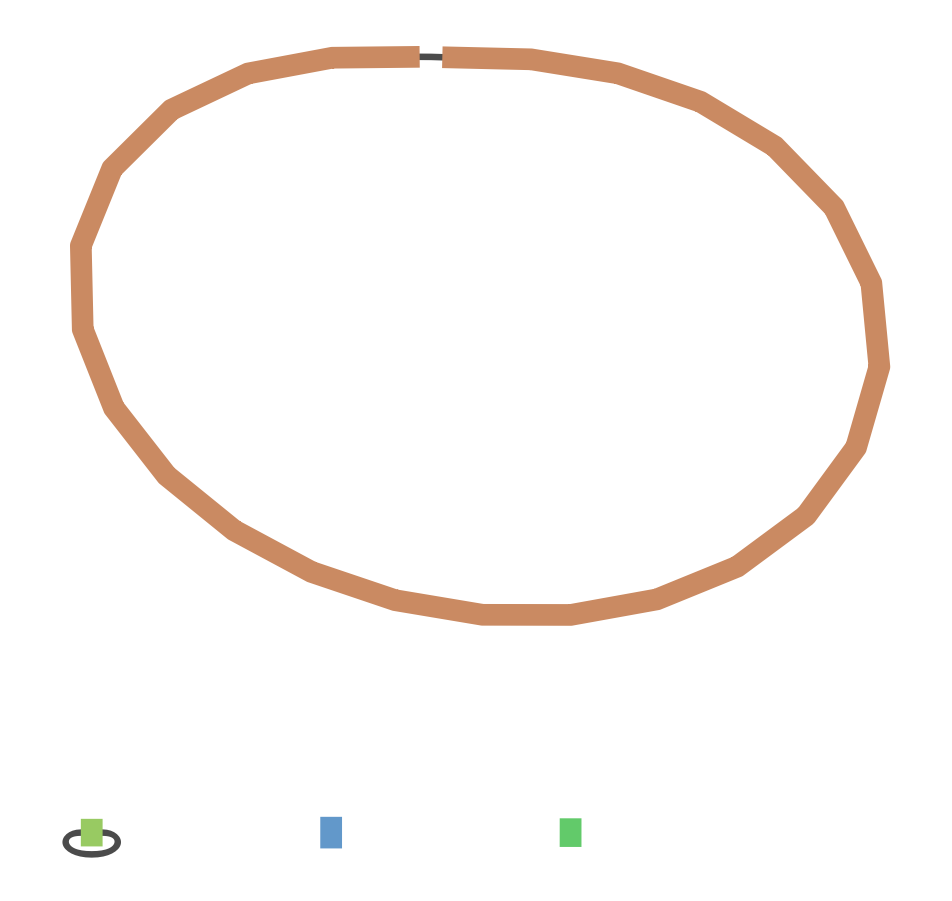

In [50]:
Image(filename=f"{resources_dir}/graphs/assembly_graph_flye.png", width=600)

In this case, the graph looks very clean, with two circular contigs, one of which is the chromosome. If the chromosome can be resolved as a single, circular contig, the assembly is called a *complete genome assembly* as opposed to a *draft assembly* which is fragmented.

However, there are two short, non-circular contigs of similar size. In cases like this, it is adviced to look at these potential plasmids a bit closer, since short plasmids can often assemble wrongly or not at all.

We therefore use *samtools* to extract only the potential plasmid sequences from the assembly, and then use BLAST to align them against themselfs and one another, revealing potential sequence duplications.

We display the result by loading the blastn output in "fmt6" into a pandas dataframe and filter by percent identity (>98 %).

In [5]:
os.system(f"samtools faidx {results_dir}/flye_assembly/assembly.fasta contig_1 contig_2 contig_3 > {results_dir}/flye_assembly/plasmids.fasta")
os.system(f"makeblastdb -in {results_dir}/flye_assembly/plasmids.fasta -dbtype nucl")
os.system(f"blastn -query {results_dir}/flye_assembly/plasmids.fasta "
          f"-db {results_dir}/flye_assembly/plasmids.fasta "
          f"-out {results_dir}/flye_assembly/plasmids_blastn.txt "
          f"-outfmt 6")
df = pd.read_csv(f"{results_dir}/flye_assembly/plasmids_blastn.txt", 
                 sep="\t", 
                 names=["qseqid", "sseqid", "pident", "length", "mismatch", "gapopen", "qstart", "qend", "sstart", "send", "evalue", "bitscore"])
df.loc[(df.qseqid != df.sseqid) & (df.pident >= 98) & (df.length >= 1000)]



Building a new DB, current time: 09/30/2025 16:31:56
New DB name:   /biodata/results/day3_lab1/flye_assembly/plasmids.fasta
New DB title:  /biodata/results/day3_lab1//flye_assembly/plasmids.fasta
Sequence type: Nucleotide
Deleted existing Nucleotide BLAST database named /biodata/results/day3_lab1/flye_assembly/plasmids.fasta
Keep MBits: T
Maximum file size: 3000000000B
Adding sequences from FASTA; added 3 sequences in 0.0162108 seconds.




,qseqid,sseqid,pident,length,mismatch,gapopen,qstart,qend,sstart,send,evalue,bitscore
38,contig_2,contig_3,99.916,2389,0,2,1,2387,2395,7,0.0,4399.0
39,contig_2,contig_3,100.000,2054,0,0,1891,3944,3516,1463,0.0,3794.0
53,contig_3,contig_2,99.916,2389,0,2,7,2395,2387,1,0.0,4399.0
54,contig_3,contig_2,100.000,2054,0,0,1463,3516,3944,1891,0.0,3794.0


As you can see, contig_2 and contig_3 are mostly identical in sequence. This is an assembly artifact, since two nearly-identical plasmids cannot co-exist inside one strain, because of replication incompatibilities. Since contig_3 is smaller than contig_2, we keep only the latter one:

In [5]:
# remove duplicated plasmid
os.system(f"samtools faidx {results_dir}/flye_assembly/assembly.fasta contig_4 contig_1 contig_2 > {results_dir}/flye_assembly/assembly_filtered.fasta")

0

In [6]:
os.system(f"medaka_consensus -i {results_dir}/ONT_filtered.fastq "
          f"-d {results_dir}/flye_assembly/assembly_filtered.fasta " 
          f"-o {results_dir}/medaka_consensus/")

Attempting to automatically select model version.
Checking program versions
This is medaka 2.1.1
Program    Version    Required   Pass     
bcftools   1.22       1.11       True     
bgzip      1.22.1     1.11       True     
minimap2   2.30       2.11       True     
samtools   1.22.1     1.11       True     
tabix      1.22.1     1.11       True     


[09:41:27 - MdlStrTGZ] Successfully removed temporary files from /tmp/tmpo8w5z18g.
[09:41:28 - MdlStrTGZ] Successfully removed temporary files from /tmp/tmp07ge_jtg.
[09:41:29 - MdlStrTGZ] Successfully removed temporary files from /tmp/tmpxy7jeimf.
[09:41:29 - MdlStrTGZ] Successfully removed temporary files from /tmp/tmp95ag2_zq.
Creating fai index file /biodata/results/day3_lab1/flye_assembly/assembly_filtered.fasta.fai
Creating mmi index file /biodata/results/day3_lab1/flye_assembly/assembly_filtered.fasta.map-ont.mmi
[M::mm_idx_gen::0.038*1.00] collected minimizers
[M::mm_idx_gen::0.047*1.37] sorted minimizers


Aligning basecalls to draft


[M::main::0.100*0.82] loaded/built the index for 3 target sequence(s)
[M::mm_idx_stat] kmer size: 15; skip: 10; is_hpc: 0; #seq: 3
[M::mm_idx_stat::0.104*0.82] distinct minimizers: 547896 (96.66% are singletons); average occurrences: 1.052; average spacing: 5.343; total length: 3080873
[M::main] Version: 2.30-r1287
[M::main] CMD: minimap2 -I 16G -x map-ont -d /biodata/results/day3_lab1/flye_assembly/assembly_filtered.fasta.map-ont.mmi /biodata/results/day3_lab1/flye_assembly/assembly_filtered.fasta
[M::main] Real time: 0.106 sec; CPU: 0.087 sec; Peak RSS: 0.032 GB
[M::main::0.015*0.98] loaded/built the index for 3 target sequence(s)
[M::mm_mapopt_update::0.019*0.99] mid_occ = 16
[M::mm_idx_stat] kmer size: 15; skip: 10; is_hpc: 0; #seq: 3
[M::mm_idx_stat::0.022*0.99] distinct minimizers: 547896 (96.66% are singletons); average occurrences: 1.052; average spacing: 5.343; total length: 3080873
[M::worker_pipeline::28.692*0.90] mapped 21793 sequences
[M::main] Version: 2.30-r1287
[M::main

Running medaka inference


[09:42:02 - Predict] Processing region(s): contig_4:0-3049602 contig_1:0-27327 contig_2:0-3944
[09:42:02 - Predict] Using model: /opt/conda/lib/python3.10/site-packages/medaka/data/r1041_e82_400bps_sup_v5.2.0_model_pt.tar.gz.
[09:42:02 - Predict] Using minimum mapQ threshold of 1 for read filtering.
[09:42:02 - MdlStrTGZ] Model GRUModel(
  (gru): GRU(10, 128, num_layers=2, batch_first=True, bidirectional=True)
  (linear): Linear(in_features=256, out_features=5, bias=True)
)
[09:42:02 - MdlStrTGZ] loading weights from /tmp/tmpa1j77sg_/model/weights.pt
[09:42:02 - MdlStrTGZ] Successfully removed temporary files from /tmp/tmpa1j77sg_.
[09:42:02 - Predict] Model device: cpu
[09:42:02 - Predict] Running prediction at full precision
[09:42:02 - Predict] Processing 5 long region(s) with batching.
[09:42:02 - PWorker] Running inference for 3.1M draft bases.
[09:46:49 - PWorker] Processed 4 batches
[09:46:49 - PWorker] All done, 0 remainder regions.
[09:46:49 - Predict] Processing 1 short regio

Polished assembly written to /biodata/results/day3_lab1//medaka_consensus//consensus.fasta, have a nice day.


0

## Processing Illumina sequencing data

The Illumina sequencing data is supplied in the resources directory. We will use the tool *trim-galore* to trim sequencing adapter from the reads and filter them by minimum quality and length.

In [9]:
os.system(f"trim_galore --quality 30 --gzip --basename 25748 --length 120 "
          f"--output_dir {results_dir}/illumina_trimmed/ "
          f"--paired {resources_dir}/raw_reads/25748_R1.fastq.gz {resources_dir}/raw_reads/25748_R2.fastq.gz")

Multicore support not enabled. Proceeding with single-core trimming.
Path to Cutadapt set as: 'cutadapt' (default)
Cutadapt seems to be working fine (tested command 'cutadapt --version')
Cutadapt version: 5.1
single-core operation.
igzip detected. Using igzip for decompressing

No quality encoding type selected. Assuming that the data provided uses Sanger encoded Phred scores (default)

Output directory /biodata/results/day3_lab1//illumina_trimmed/ doesn't exist, creating it for you...



igzip command line interface 2.31.1


Output will be written into the directory: /biodata/results/day3_lab1/illumina_trimmed/
Using user-specified basename (>>25748<<) instead of deriving the filename from the input file(s)
igzip: Error encountered while writing to file (null)


AUTO-DETECTING ADAPTER TYPE
Attempting to auto-detect adapter type from the first 1 million sequences of the first file (>> /biodata/resources/day3_lab1//raw_reads/25748_R1.fastq.gz <<)

Found perfect matches for the following adapter sequences:
Adapter type	Count	Sequence	Sequences analysed	Percentage
Nextera	47	CTGTCTCTTATA	1000000	0.00
Illumina	0	AGATCGGAAGAGC	1000000	0.00
smallRNA	0	TGGAATTCTCGG	1000000	0.00
Using Nextera adapter for trimming (count: 47). Second best hit was Illumina (count: 0)

igzip: Error encountered while writing to file (null)
Writing report to '/biodata/results/day3_lab1/illumina_trimmed/25748_R1.fastq.gz_trimming_report.txt'

SUMMARISING RUN PARAMETERS
Input filename: /biodata/resources/day3_lab1//raw_reads/25748_R1.fast

0

The tool *fastqc* generates HTML reports of Illumina read sets for Quality Control:

In [10]:
os.system(f"mkdir -p {results_dir}/fastqc_reports/")
os.system(f"fastqc -o {results_dir}/fastqc_reports/ {results_dir}/illumina_trimmed/25748_val_1.fq.gz {results_dir}/illumina_trimmed/25748_val_2.fq.gz")

application/gzip
application/gzip


Started analysis of 25748_val_1.fq.gz
Approx 5% complete for 25748_val_1.fq.gz
Approx 10% complete for 25748_val_1.fq.gz
Approx 15% complete for 25748_val_1.fq.gz
Approx 20% complete for 25748_val_1.fq.gz
Approx 25% complete for 25748_val_1.fq.gz
Approx 30% complete for 25748_val_1.fq.gz
Approx 35% complete for 25748_val_1.fq.gz
Approx 40% complete for 25748_val_1.fq.gz
Approx 45% complete for 25748_val_1.fq.gz
Approx 50% complete for 25748_val_1.fq.gz
Approx 55% complete for 25748_val_1.fq.gz
Approx 60% complete for 25748_val_1.fq.gz
Approx 65% complete for 25748_val_1.fq.gz
Approx 70% complete for 25748_val_1.fq.gz
Approx 75% complete for 25748_val_1.fq.gz
Approx 80% complete for 25748_val_1.fq.gz
Approx 85% complete for 25748_val_1.fq.gz
Approx 90% complete for 25748_val_1.fq.gz
Approx 95% complete for 25748_val_1.fq.gz


Analysis complete for 25748_val_1.fq.gz


Started analysis of 25748_val_2.fq.gz
Approx 5% complete for 25748_val_2.fq.gz
Approx 10% complete for 25748_val_2.fq.gz
Approx 15% complete for 25748_val_2.fq.gz
Approx 20% complete for 25748_val_2.fq.gz
Approx 25% complete for 25748_val_2.fq.gz
Approx 30% complete for 25748_val_2.fq.gz
Approx 35% complete for 25748_val_2.fq.gz
Approx 40% complete for 25748_val_2.fq.gz
Approx 45% complete for 25748_val_2.fq.gz
Approx 50% complete for 25748_val_2.fq.gz
Approx 55% complete for 25748_val_2.fq.gz
Approx 60% complete for 25748_val_2.fq.gz
Approx 65% complete for 25748_val_2.fq.gz
Approx 70% complete for 25748_val_2.fq.gz
Approx 75% complete for 25748_val_2.fq.gz
Approx 80% complete for 25748_val_2.fq.gz
Approx 85% complete for 25748_val_2.fq.gz
Approx 90% complete for 25748_val_2.fq.gz
Approx 95% complete for 25748_val_2.fq.gz


Analysis complete for 25748_val_2.fq.gz


0

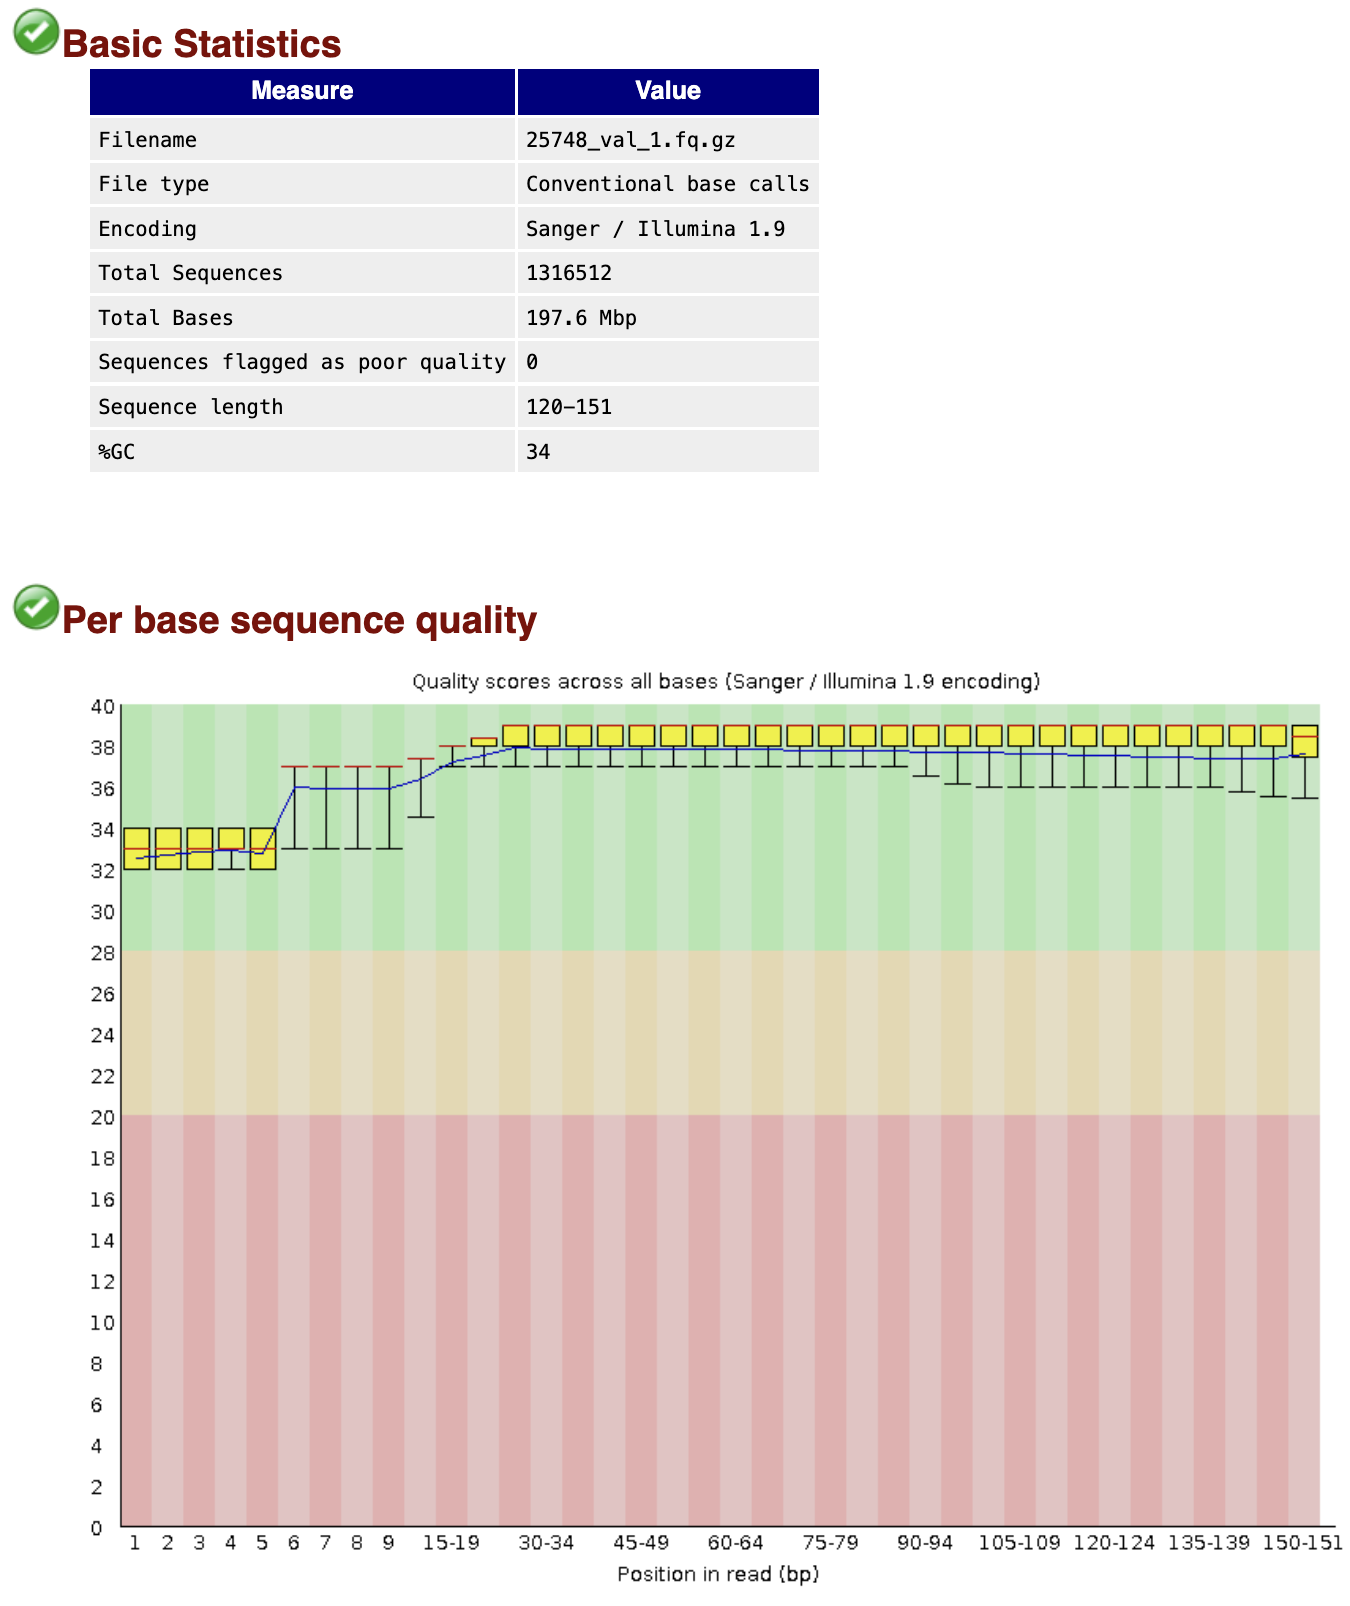

In [48]:
Image(filename=f"{resources_dir}/fastqc/fastqc_R1.png", width=600)

We can see that the mean quality of the Illumina reads is close to 40, meaning an error rate of just under 0.0001 or one error per 10 Kbps. 

Additionally, we see that there are ~200 Mbp. Since we have paired-read Illumina data, the total bases are close to 400 Mbp, which is equivalent to an estimated sequencing depth of 130x.

Let us now use *spades* for creating a Illumina-only genome assembly for comparison to the ONT-only assembly:

In [12]:
os.system(f"mkdir -p {results_dir}/spades")
os.system(f"spades.py --isolate -o {results_dir}/spades/ --threads 8 --memory 16 "
          f"-1 {results_dir}/illumina_trimmed/25748_val_1.fq.gz "
          f"-2 {results_dir}/illumina_trimmed/25748_val_2.fq.gz ")

Command line: /opt/conda/bin/spades.py	--isolate	-o	/biodata/results/day3_lab1/spades	--threads	8	--memory	16	-1	/biodata/results/day3_lab1/illumina_trimmed/25748_val_1.fq.gz	-2	/biodata/results/day3_lab1/illumina_trimmed/25748_val_2.fq.gz	

System information:
  SPAdes version: 4.2.0
  Python version: 3.10.18
  OS: Linux-6.10.14-linuxkit-aarch64-with-glibc2.39

Output dir: /biodata/results/day3_lab1/spades
Mode: ONLY assembling (without read error correction)
Debug mode is turned OFF

Dataset parameters:
  Isolate mode
  Reads:
    Library number: 1, library type: paired-end
      orientation: fr
      left reads: ['/biodata/results/day3_lab1/illumina_trimmed/25748_val_1.fq.gz']
      right reads: ['/biodata/results/day3_lab1/illumina_trimmed/25748_val_2.fq.gz']
      interlaced reads: not specified
      single reads: not specified
      merged reads: not specified
Assembly parameters:
  k: automatic selection based on read length
  Repeat resolution is enabled
  Mismatch careful mod

0

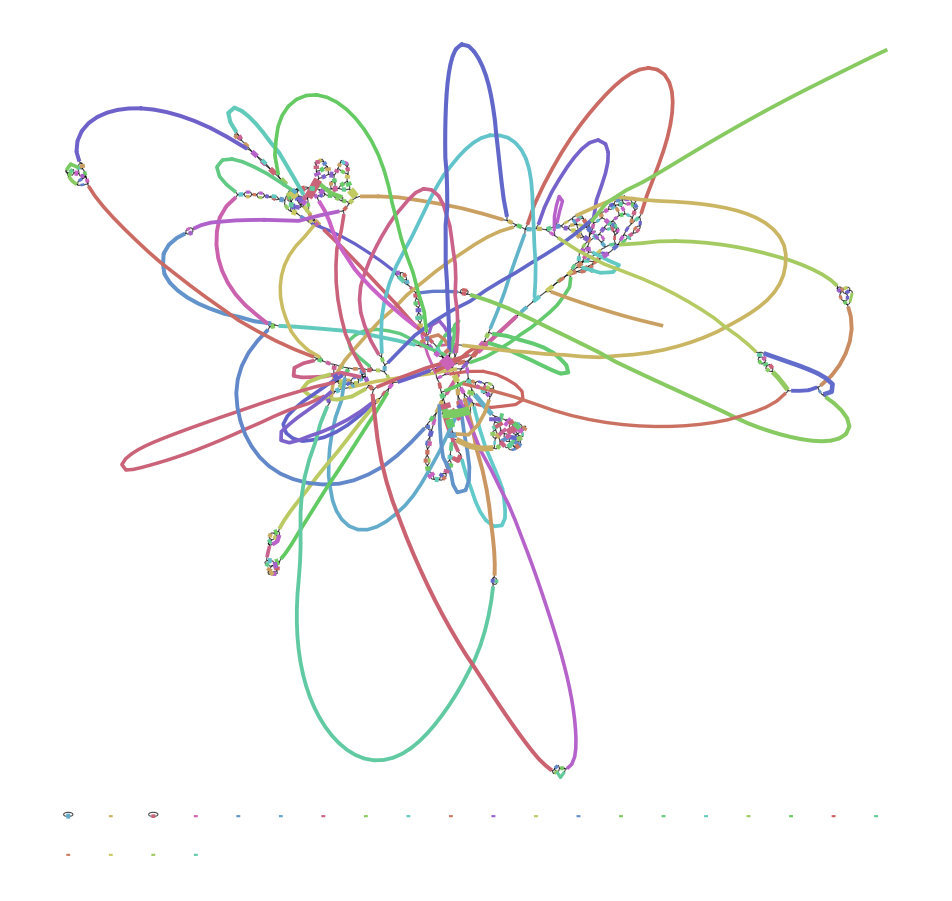

In [51]:
Image(filename=f"{resources_dir}/graphs/assembly_graph_spades.png", width=600)

As we can see when visualizing the assembly in *Bandage*, it is heavily fragmented and far from being complete. In total, *spades* generated 466 contigs with 607 nodes in the assembly graph. This reveals the advantage of using long-read sequencing for genome assembly: Despite having only approximately a third of the sequencing depth, the ONT-only assembly generated a complete, circular chromosome.

# Short-Read Polishing

We can make use of the benefits of both technologies, the completeness of assemblies of long Nanopore reads and the superior quality of the short Illumina reads, by using the latter for **short–read polishing**. For this purpose, we will use the tool *polypolish*, which maps the short reads to all matching positions in the ONT-only assembly and then corrects genomic positions if the vast majority of bases in illumina reads at a given position is different to the base in the assembly. Due to the superior quality of the Illumina reads, it is safe to assume that in these cases, the assembly contains errors that need to be corrected.

In the following, we perform this short-read polishing step on two different assembly stages: Prior to and after the medaka polishing step, to be able to compare how well medaka polishing compares to polishing with illumina reads.

In [31]:
os.system(f"mkdir -p {results_dir}/polypolish")
for reference,suffix in [
        (f"{results_dir}/medaka_consensus/consensus.fasta", ""),
        (f"{results_dir}/flye_assembly/assembly_filtered.fasta", "_flye")
        ]:
    # index the assembly
    os.system(f"bwa index {reference}")
    # map the short reads to it using bwa mem
    os.system(f"bwa mem -t 16 -a {reference} {results_dir}/illumina_trimmed/25748_val_1.fq.gz > {results_dir}/polypolish/25748_val_1.sam")
    os.system(f"bwa mem -t 16 -a {reference} {results_dir}/illumina_trimmed/25748_val_2.fq.gz > {results_dir}/polypolish/25748_val_2.sam")
    # polish with polypolish
    os.system(f"polypolish filter "
              f"--in1  {results_dir}/polypolish/25748_val_1.sam --in2  {results_dir}/polypolish/25748_val_2.sam "
              f"--out1 {results_dir}/polypolish/filtered_1.sam  --out2 {results_dir}/polypolish/filtered_2.sam ")
    os.system(f"polypolish polish --debug {results_dir}/polypolish/polished{suffix}.tsv {reference} "
              f"{results_dir}/polypolish/filtered_1.sam {results_dir}/polypolish/filtered_2.sam "
              f"> {results_dir}/polypolish/polished{suffix}.fasta")
    os.system(f"rm {results_dir}/polypolish/*.sam")

[bwa_index] Pack FASTA... 0.03 sec
[bwa_index] Construct BWT for the packed sequence...
[bwa_index] 0.39 seconds elapse.
[bwa_index] Update BWT... 0.01 sec
[bwa_index] Pack forward-only FASTA... 0.01 sec
[bwa_index] Construct SA from BWT and Occ... 0.11 sec
[main] Version: 0.7.19-r1273
[main] CMD: bwa index /biodata/results/day3_lab1//medaka_consensus/consensus.fasta
[main] Real time: 0.564 sec; CPU: 0.550 sec
[M::bwa_idx_load_from_disk] read 0 ALT contigs
[M::process] read 1065898 sequences (160000195 bp)...
[M::process] read 250614 sequences (37602740 bp)...
[M::mem_process_seqs] Processed 1065898 reads in 43.106 CPU sec, 4.484 real sec
[M::mem_process_seqs] Processed 250614 reads in 9.935 CPU sec, 1.069 real sec
[main] Version: 0.7.19-r1273
[main] CMD: bwa mem -t 16 -a /biodata/results/day3_lab1//medaka_consensus/consensus.fasta /biodata/results/day3_lab1//illumina_trimmed/25748_val_1.fq.gz
[main] Real time: 11.577 sec; CPU: 56.368 sec
[M::bwa_idx_load_from_disk] read 0 ALT contigs


We now read the TSV files generated by polypolish that summarize how many changes to the assemblies were made based on the short-read polishing:

In [6]:
pd.concat([
    pd.read_csv(f"{results_dir}/polypolish/polished.tsv", sep="\t").status.value_counts().to_frame().T.set_index(pd.Index(["medaka polished"])),
    pd.read_csv(f"{results_dir}/polypolish/polished_flye.tsv", sep="\t").status.value_counts().to_frame().T.set_index(pd.Index(["fyle assembly"]))
]).fillna(0.).astype({"changed" : int})

status,kept,low_depth,multiple,too_close,none,changed
medaka polished,3077825,1722,732,585,1,0
fyle assembly,3077825,1722,732,585,1,8


As you can see, in this case, short-read polishing had no benefit compared to medaka polishing, since no additional changes were made. As impressive as this result is, it is important to consider that ONT-only assemblies are not always of this high quality. Several factors influence the quality of an assembly, amond others:

- DNA extraction kit & pusity of the extracted DNA
- degree of DNA fragmentation
- DNA methylation
- presence and quantity of low-complexity regions, repetitive sequences and mobile genetic elements 
- GC content
- presence and relative quantity of plasmid DNA
- homopolymer regions

## Finalizing the Assembly

The final steps of Genome assembly that need to be performed are **re-orientation**, **quality and completeness assessment** and **gene prediction**.

### Re-Orientation

Bacterial replicons - chromosomes and plasmids - are circular. However, we represent these sequences as linear in files like FASTA files. After genome assembly, the "breaking point" where the circular sequence is opened to form a linear sequence is arbitrary for each replicon. It is a convention to change that for complete genome assemblies by changing the first base to the start of certain genes, e.g. dnaA in bacterial genomes.

We will use the tool **dnaapler** to perform this re-orientation. However, we need to be careful to only do this for circular contigs, because this operation is not permitted for linear fragments. We will therefor first extract a list of non-circular contig IDs from the flye output: 

In [36]:
os.system(f'awk \'$4 == "N" {{print$1}}\' {results_dir}/flye_assembly/assembly_info.txt > {results_dir}/flye_assembly/non_circular_contigs.txt')
os.system(f"cat {results_dir}/flye_assembly/non_circular_contigs.txt")

contig_2
contig_3


0

We now use this list as input for **dnaapler**, telling it to ignore these contigs:

In [39]:
os.system(f"dnaapler all -i {results_dir}/polypolish/polished.fasta "
          f"-o {results_dir}/dnaapler/ -f -p polished -t 8 "
          f"--ignore {results_dir}/flye_assembly/non_circular_contigs.txt")
pd.read_csv(f"{results_dir}/dnaapler/polished_all_reorientation_summary.tsv", sep="\t")

2025-09-30 12:38:42.867 | INFO     | dnaapler.utils.validation:instantiate_dirs:24 - Checking the output directory /biodata/results/day3_lab1//dnaapler/
2025-09-30 12:38:42.873 | INFO     | dnaapler.utils.util:begin_dnaapler:74 - You are using dnaapler version 1.3.0
2025-09-30 12:38:42.873 | INFO     | dnaapler.utils.util:begin_dnaapler:75 - Repository homepage is https://github.com/gbouras13/dnaapler
2025-09-30 12:38:42.873 | INFO     | dnaapler.utils.util:begin_dnaapler:76 - Written by George Bouras: george.bouras@adelaide.edu.au
2025-09-30 12:38:42.873 | INFO     | dnaapler.utils.util:begin_dnaapler:77 - Your input file is /biodata/results/day3_lab1//polypolish/polished.fasta
2025-09-30 12:38:42.873 | INFO     | dnaapler.utils.util:begin_dnaapler:78 - Your output directory  is /biodata/results/day3_lab1//dnaapler/
2025-09-30 12:38:42.873 | INFO     | dnaapler.utils.util:begin_dnaapler:79 - You have specified 8 threads to use with MMseqs2
2025-09-30 12:38:42.873 | INFO     | dnaapler

mmseqs easy-search /biodata/results/day3_lab1//dnaapler/rotated_input.fasta /opt/conda/lib/python3.10/site-packages/dnaapler/db/all_db /biodata/results/day3_lab1/dnaapler/polished_MMseqs2_output.txt /biodata/results/day3_lab1/dnaapler/tmp_MMseqs2_output --search-type 2  --threads 8 -e 1e-10 --format-output query,qlen,target,tlen,alnlen,qstart,qend,tstart,tend,fident,nident,gapopen,mismatch,evalue,bits,qaln,taln


2025-09-30 12:38:51.565 | INFO     | dnaapler.utils.external_tools:run:54 - Done running mmseqs easy-search /biodata/results/day3_lab1//dnaapler/rotated_input.fasta /opt/conda/lib/python3.10/site-packages/dnaapler/db/all_db /biodata/results/day3_lab1/dnaapler/polished_MMseqs2_output.txt /biodata/results/day3_lab1/dnaapler/tmp_MMseqs2_output --search-type 2 --threads 8 -e 1e-10 --format-output query,qlen,target,tlen,alnlen,qstart,qend,tstart,tend,fident,nident,gapopen,mismatch,evalue,bits,qaln,taln
2025-09-30 12:38:51.633 | INFO     | dnaapler.utils.util:end_dnaapler:173 - dnaapler has finished
2025-09-30 12:38:51.633 | INFO     | dnaapler.utils.util:end_dnaapler:174 - Elapsed time: 8.76 seconds


,Contig,Gene_Reoriented,Start,Strand,Top_Hit,Top_Hit_Length,Covered_Length,Coverage,Identical_AAs,Identity_Percentage,Overlapping_Contig_End
0,contig_4 polypolish,dnaA,2664071,forward,sp~Q6GKU4~DNAA_STAAR,453,453,100.0,453,100.0,False
1,contig_1 polypolish,repA,22361,forward,UniRef90_D2J623,314,314,100.0,314,100.0,False
2,contig_2 polypolish,Contig_ignored,Contig_ignored,Contig_ignored,Contig_ignored,Contig_ignored,Contig_ignored,Contig_ignored,Contig_ignored,Contig_ignored,Contig_ignored


As you can see, contig_4 was re-oriented to dnaA (Top_Hit : sp~Q6GKU4~DNAA_STAAR), and contig_2 was ignored as intended.

<div style="border-left: 4px solid #007acc; padding: 0.5em; background: rgba(0, 122, 204, 0.1); border-radius: 4px;">
<strong>📝 Question :</strong> What was contig_1 re-oriented to?
</div>

<details>
<summary><strong>🔎 Solution :</strong></summary>

The hit against UniRef90_D2J623 is a gene encoding the "Replication initiator protein A", which again validates that this contig is not an assembly artifact.

</details>

### Check Assembly Qualtity and Completeness

We are now going to use **CheckM** to control the quality and completeness of the assembly. However, since this tool requires ~40 GB of RAM, we will use precompiled results for this assembly for dempnstration purposes.

In [41]:
os.system(f"mkdir -p {results_dir}/checkm")
#os.system(f"checkm lineage_wf -t 2 -x fasta {results_dir}/polypolish/ {results_dir}/checkm/") # requires ~40 GB of RAM
#os.system(f"checkm qa -o 2 --tab_table {results_dir}/checkm/lineage.ms {results_dir}/checkm/ -f {results_dir}/checkm/assembly.tsv")
os.system(f"cp -r {resources_dir}/checkm {results_dir}/")
pd.read_csv(f"{results_dir}/checkm/assembly.tsv", sep="\t")

,Bin Id,Marker lineage,# genomes,# markers,# marker sets,Completeness,Contamination,Strain heterogeneity,Genome size (bp),# ambiguous bases,...,GC std (scaffolds > 1kbp),Coding density,Translation table,# predicted genes,0,1,2,3,4,5+
0,polished_reoriented,g__Staphylococcus (UID301),45,940,178,99.51,0.08,0.0,3080865,0,...,1.85,83.72,11,2904,4,935,1,0,0,0


As we can see, the completeness and contamination values are very close to the optimal values of 100.0 and 0.0, respectively. This indicates a really high assembly quality.

Also, we now see the genus of our isolate: *Staphylococcus* ! In fact, it is a clinically relevant *Staphylococcus aureus* strain BPH2947.

<div style="border-left: 4px solid #007acc; padding: 0.5em; background: rgba(0, 122, 204, 0.1); border-radius: 4px;">
<strong>📝 Task :</strong> Compare to published assembly
<br>
The NCBI accession number <a href="https://www.ncbi.nlm.nih.gov/datasets/genome/GCF_045345275.1/" target="_blank">GCA_045345275.1</a> is based on the same data (without 50x subsampling).
<br>
What are possible reasons for the observed differences?
</div>

<details>
<summary><strong>🔎 Solution :</strong></summary>

<ul>
  <li>Same number of contigs with nearly identical sizes, only the size of the smallest plasmid differs.</li>
  <li>For our assembly, the completeness is higher and contamination is lower. Reason: <b>Newer basecalling model.</b></li>
</ul> 

</details>

### Gene Prediction

The last step we perform is predicting genes from the assembly with *prokka*.

In [42]:
# Gene prediction with Prokka
#os.system(f"prokka --outdir {results_dir}/prokka/ --prefix Saureus_BPH2947 {results_dir}/polypolish/polished_reoriented.fasta") # does not run on ARM architecture
os.system(f"cp -r {resources_dir}/prokka {results_dir}/")

# show data format
print(f"{results_dir}/prokka/Saureus_BPH2947.fna : ")
os.system(f"head -n 10 {results_dir}/prokka/Saureus_BPH2947.fna")
print(f"\n{results_dir}/prokka/Saureus_BPH2947.gff : ")
os.system(f"head -n 10 {results_dir}/prokka/Saureus_BPH2947.gff")

/biodata/results/day3_lab1//prokka/Saureus_BPH2947.fna : 
>contig_4
ATGTCGGAAAAAGAAATTTGGGAAAAAGTGCTTGAAATTGCTCAAGAAAAATTATCAGCT
GTAAGTTACTCAACTTTCCTAAAAGATACTGAGCTTTACACGATCAAAGATGGTGAAGCT
ATCGTATTATCGAGTATTCCTTTTAATGCAAATTGGTTAAATCAACAATATGCTGAAATT
ATCCAAGCAATCTTATTTGATGTTGTAGGCTATGAAGTAAAACCTCACTTTATTACTACT
GAAGAATTAGCAAATTATAGTAATAATGAAACTGCTACTCCAAAAGAAGCAACAAAACCT
TCTACTGAAACAACTGAGGATAATCATGTGCTTGGTAGAGAGCAATTCAATGCCCATAAC
ACATTTGACACTTTTGTAATCGGACCTGGTAACCGCTTCCCACATGCAGCGAGTTTAGCT
GTGGCCGAAGCACCAGCCAAAGCGTACAATCCATTATTTATCTATGGAGGTGTTGGTTTA
GGAAAAACCCATTTAATGCATGCCATTGGTCATCATGTTTTAGATAATAATCCAGATGCC

/biodata/results/day3_lab1//prokka/Saureus_BPH2947.gff : 
##gff-version 3
##sequence-region contig_4 1 3049602
##sequence-region contig_1 1 27319
##sequence-region contig_2 1 3944
contig_4	Prodigal:002006	CDS	1	1362	.	+	0	ID=MIKAGACI_00001;Name=dnaA;gene=dnaA;inference=ab initio prediction:Prodigal:002006,similar to AA sequence:UniProtKB:P68866;locus_tag=MIKAGACI_00001;product=Ch

0

As you can see, the GFF file created by prokka annotated genes with start and stop coordinates, as well as predicted products. Also, note that as intended, the first gene at position 1 is dnaA.

### Taxonomic Assignment

At this point, we would perform a taxonomic assignment of our isolate using the tool *GTDB-tk*. However, this requires a large GTDB Reference Data bank, which is why it is not part of this tutorial.

## Query Gene Annotations

We now want to use the gene predictions for a really simple example by seaching for antibiotic or antimicrobial resistance (AMR) genes. There are specialized tools for that process that produce more robust results, but this is just a quick demonstration:

# 

In [43]:
os.system(f"grep resistance {results_dir}/prokka/Saureus_BPH2947.gff")

contig_4	Prodigal:002006	CDS	60698	61105	.	+	0	ID=MIKAGACI_00058;Name=merR1_1;gene=merR1_1;inference=ab initio prediction:Prodigal:002006,similar to AA sequence:UniProtKB:P22853;locus_tag=MIKAGACI_00058;product=Mercuric resistance operon regulatory protein
contig_4	Prodigal:002006	CDS	81676	81879	.	+	0	ID=MIKAGACI_00080;Name=mecI;gene=mecI;inference=ab initio prediction:Prodigal:002006,similar to AA sequence:UniProtKB:P68261;locus_tag=MIKAGACI_00080;product=Methicillin resistance regulatory protein MecI
contig_4	Prodigal:002006	CDS	90625	90990	.	-	0	ID=MIKAGACI_00089;Name=cadC_1;gene=cadC_1;inference=ab initio prediction:Prodigal:002006,similar to AA sequence:UniProtKB:P20047;locus_tag=MIKAGACI_00089;product=Cadmium resistance transcriptional regulatory protein CadC
contig_4	Prodigal:002006	CDS	109293	110684	.	-	0	ID=MIKAGACI_00110;Name=farB_1;gene=farB_1;inference=ab initio prediction:Prodigal:002006,similar to AA sequence:UniProtKB:Q9RQ29;locus_tag=MIKAGACI_00110;product=Fatty acid r

0

By scanning through this output, we can see that there are genes predicted to encode products that convey resistance to antibiotics Methicillin, Quinolone, Tetracycline, Linearmycin and Bicyclomycin. In addition we found multiple heavy-metal and multidrug resistance genes.

ⓘ Note: This only shows the **genetic potential** of the strain and not if these genes are actually expressed. For this, we would need to either test for resistances directly by plating the strain on media containing antibiotics, or by performing **RNA-seq** to see which genes are expressed.

# Resources

The sequencing data used in this tutorial was originally published by Hall et al. in 2024 : https://doi.org/10.7554/eLife.98300

ONT RAW data  : https://figshare.unimelb.edu.au/ndownloader/files/45334549

Illumina data : https://www.ncbi.nlm.nih.gov/sra/?term=ERR2929425
